<a href="https://colab.research.google.com/github/sashachereshnya-pixel/compling2025/blob/main/%D0%A7%D0%95%D0%A0%D0%95%D0%92%D0%98%D0%9A_%D1%81%D0%B5%D0%BC%D0%B8%D0%BD%D0%B0%D1%80%2B%D0%94%D0%97_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **RNN/LSTM**

Цель семинара: получить практический опыт работы с RNN (LSTM) в PyTorch на задачах генерации последовательностей

Мы разберем полный пайплайн разработки от препроцессинга данных до обучения и экспериментов с гиперпараметрами

Кстати, что мы называем **пайплайном**?

В Google Colab (рекомендуется активировать GPU: `Среда выполнения → Сменить среду выполнения → T4 GPU`)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import reuters

### **ЧАСТЬ 1: ДЕМО**
*   **Задача модели:** предсказание случайного временного ряда (синусоида)
*   **Цель демонстрации:** показать полный и минимальный рабочий пайплайн RNN на задаче, связанной с обработкой данных, передающих изменения во времени
*   **План:**
    1.  Подготовка последовательностей (sequences)
    2.  Архитектура `nn.LSTM`
    3.  Обучение модели
    4.  Получение метрик оценки
    5.  Визуализация и интерпретация результата

### 1. ГЕНЕРАЦИЯ И ПОДГОТОВКА ДАННЫХ

In [ ]:
def generate_sine_wave(seq_length=1000, periods=5):
    """Генерация синусоиды."""
    x = np.linspace(0, periods * 2 * np.pi, seq_length)
    y = np.sin(x)
    return y

# Генерация данных
data = generate_sine_wave()
print(f"Длина временного ряда: {len(data)}")

Длина временного ряда: 1000


In [ ]:
# Параметры последовательностей
SEQ_LEN = 50  # Длина входной последовательности для предсказания
BATCH_SIZE = 16

In [ ]:
def create_sequences(data, seq_len):
    """Создание пар (входная последовательность, целевое значение)."""
    sequences = []
    targets = []
    for i in range(len(data) - seq_len - 1):
        seq = data[i:i + seq_len]
        target = data[i + seq_len]
        sequences.append(seq)
        targets.append(target)
    return np.array(sequences), np.array(targets)

In [ ]:
# Создание последовательностей
X, y = create_sequences(data, SEQ_LEN)
print(f"Форма X (последовательности): {X.shape}")
print(f"Форма y (цели): {y.shape}")

Форма X (последовательности): (949, 50)
Форма y (цели): (949,)


In [ ]:
# Преобразование в тензоры PyTorch и добавление размерности для признаков
X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # [примеры, SEQ_LEN, 1]
y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # [примеры, 1]
print(f"Форма X (тензор): {X.shape}")
print(f"Форма y (тензор): {y.shape}")

Форма X (тензор): torch.Size([949, 50, 1])
Форма y (тензор): torch.Size([949, 1])


In [ ]:
# Разделение на обучающую и тестовую выборки
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [ ]:
### 2. ОПРЕДЕЛЕНИЕ МОДЕЛИ LSTM
class SineLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True  # формат [batch, seq_len, features]
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Инициализация скрытого состояния и состояния ячейки
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        # Прямой проход через LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Берем только последний выход последовательности для предсказания
        out = self.fc(out[:, -1, :])
        return out

In [ ]:
# Инициализация модели
model = SineLSTM()
print(f"Модель:\n{model}")

Модель:
SineLSTM(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


### 3. ОБУЧЕНИЕ МОДЕЛИ

In [ ]:
# Гиперпараметры
EPOCHS = 20
LEARNING_RATE = 0.01

# Функция потерь и оптимизатор
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Тренировочный цикл
train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    model.train()

    # Прямой проход
    predictions = model(X_train)
    loss = criterion(predictions, y_train)

    # Обратное распространение
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Оценка на тестовой выборке
    model.eval()
    with torch.no_grad():
        test_predictions = model(X_test)
        test_loss = criterion(test_predictions, y_test)
        test_losses.append(test_loss.item())

    if (epoch + 1) % 5 == 0:
        print(f'Эпоха [{epoch+1}/{EPOCHS}], '
              f'Ошибка обучения: {loss.item():.6f}, '
              f'Ошибка теста: {test_loss.item():.6f}')

Эпоха [5/20], Ошибка обучения: 0.596939, Ошибка теста: 0.034265
Эпоха [10/20], Ошибка обучения: 0.138357, Ошибка теста: 0.116663
Эпоха [15/20], Ошибка обучения: 0.050937, Ошибка теста: 0.042962
Эпоха [20/20], Ошибка обучения: 0.040025, Ошибка теста: 0.020846


### 4. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ

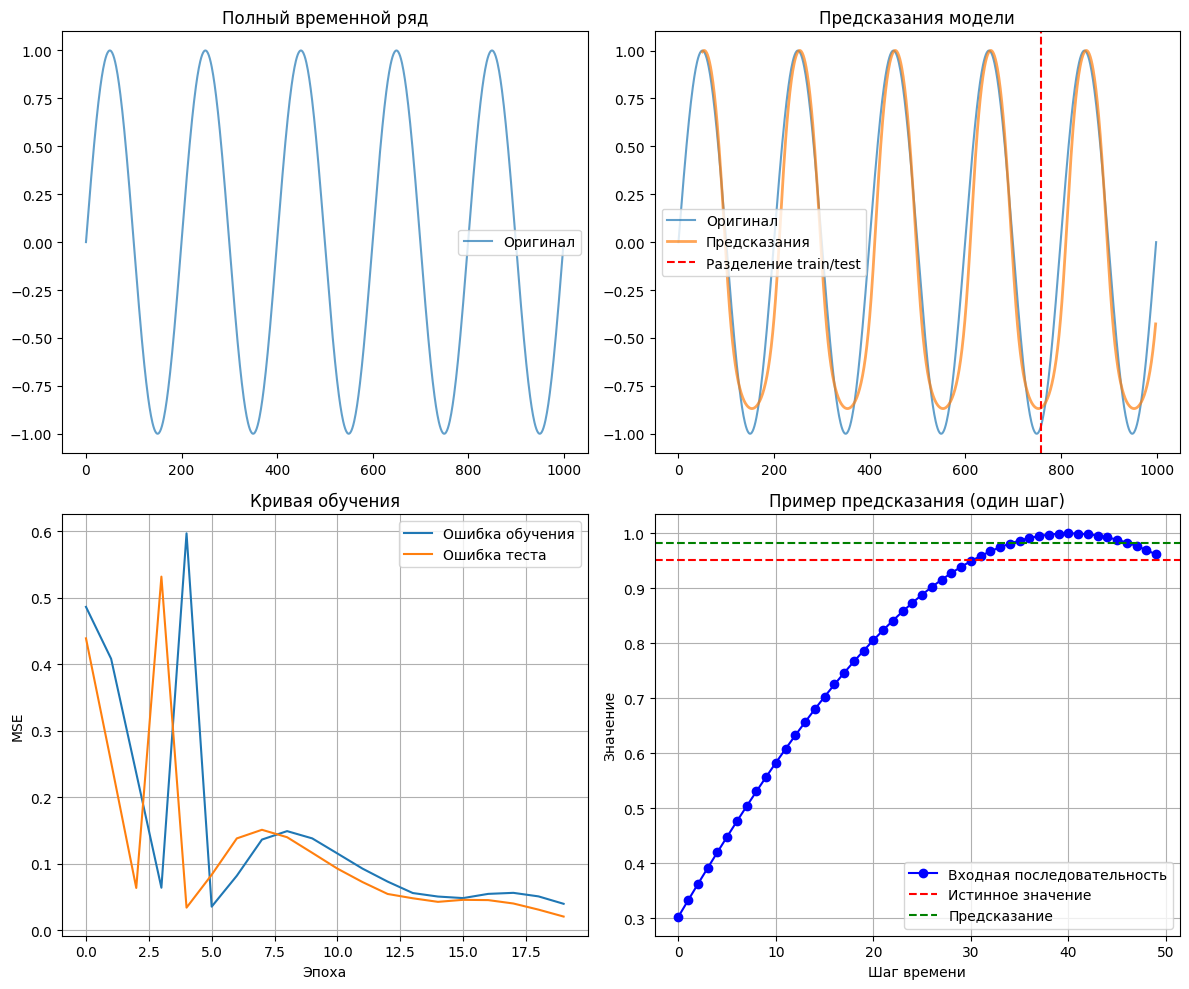

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# График 1: Оригинальные данные и предсказания
axes[0, 0].plot(data, label='Оригинал', alpha=0.7)
axes[0, 0].set_title('Полный временной ряд')
axes[0, 0].legend()

# График 2: Предсказания на тестовой выборке
model.eval()
with torch.no_grad():
    all_predictions = model(X).numpy()

# Создание массива для отображения предсказаний
pred_series = np.full_like(data, np.nan)
pred_series[SEQ_LEN:SEQ_LEN + len(all_predictions)] = all_predictions.squeeze()

axes[0, 1].plot(data, label='Оригинал', alpha=0.7)
axes[0, 1].plot(pred_series, label='Предсказания', alpha=0.7, linewidth=2)
axes[0, 1].axvline(x=split_idx, color='r', linestyle='--', label='Разделение train/test')
axes[0, 1].set_title('Предсказания модели')
axes[0, 1].legend()

# График 3: Ошибки обучения и теста
axes[1, 0].plot(train_losses, label='Ошибка обучения')
axes[1, 0].plot(test_losses, label='Ошибка теста')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('MSE')
axes[1, 0].set_title('Кривая обучения')
axes[1, 0].legend()
axes[1, 0].grid(True)

# График 4: Пример одного предсказания
sample_idx = split_idx + 50
axes[1, 1].plot(range(SEQ_LEN), X[sample_idx].squeeze().numpy(),
                'bo-', label='Входная последовательность')
axes[1, 1].axhline(y=y[sample_idx].item(), color='r', linestyle='--',
                   label='Истинное значение')
axes[1, 1].axhline(y=all_predictions[sample_idx].item(), color='g',
                   linestyle='--', label='Предсказание')
axes[1, 1].set_xlabel('Шаг времени')
axes[1, 1].set_ylabel('Значение')
axes[1, 1].set_title('Пример предсказания (один шаг)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

### 5. ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ
1. Кривая обучения должна снижаться на обеих выборках
2. Предсказания должны следовать за оригинальным рядом
3. Разрыв между train/test loss указывает на переобучение
4. Модель учится предсказывать следующий шаг синусоиды

Take aways:

1. Подготовка последовательностей: как из временного ряда создаются пары (окно истории -> целевое значение)?

2. Архитектура LSTM: batch_first=True, почему берем out[:, -1, :]

3. Цикл обучения: разделение на model.train() и model.eval(), логика .zero_grad(), .backward(), .step()

4. Визуализация: как интерпретировать каждый из 4-х графиков?

---

# ПРАКТИКА

1. ЗАГРУЗКА И ПРЕДВАРИТЕЛЬНЫЙ ПРОСМОТР ДАННЫХ

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import reuters

# TODO 1.1: Загрузите датасет Reuters
(x_train, y_train), (x_test, y_test) = reuters.load_data()

# TODO 1.2: Изучите структуру данных
print("Тип x_train:", type(x_train))
print("Длина x_train:", len(x_train))
print("Первая последовательность (первые 10 индексов):", x_train[0][:10])
print("Длина первой последовательности:", len(x_train[0]))

Тип x_train: <class 'numpy.ndarray'>
Длина x_train: 8982
Первая последовательность (первые 10 индексов): [1, 27595, 28842, 8, 43, 10, 447, 5, 25, 207]
Длина первой последовательности: 87


2. ПОДГОТОВКА СЛОВАРЯ И ДЕКОДИРОВАНИЕ

In [ ]:
# TODO 2.1: Загрузите словарь слов
word_index = reuters.get_word_index()
reverse_word_index = {value: key for (key, value) in word_index.items()}

# TODO 2.2: Реализуйте функцию декодирования последовательности
def decode_sequence(sequence):
    return ' '.join([reverse_word_index.get(i-3, '?') for i in sequence])

first_article = decode_sequence(x_train[0])
print("\nПервая статья (первые 200 символов):", first_article[:200])


Первая статья (первые 200 символов): ? mcgrath rentcorp said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net shou


3. ПОДГОТОВКА ДАННЫХ ДЛЯ ГЕНЕРАЦИИ ТЕКСТА

In [ ]:
# TODO 3.1: Объедините первые 1000 статей в один текст
max_articles = 1000
max_articles_idx = x_train[:max_articles]
max_articles_texts = [decode_sequence(seq) for seq in max_articles_idx]
texts = ' '.join(max_articles_texts)

print(f"Общая длина текста (символов): {len(texts)}")
print("Пример текста:", texts[:500])

# TODO 3.2: Создайте словари для преобразования символов в индексы и обратно
chars = sorted(list(set(texts)))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

vocab_size = len(chars)
print(f"Размер словаря (уникальных символов): {vocab_size}")

# TODO 3.3: Преобразуйте текст в последовательность индексов
text_as_int = [char_to_idx[ch] for ch in texts]

seq_length = 100


Общая длина текста (символов): 815340
Пример текста: ? mcgrath rentcorp said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3 ? generale de banque sa lt genb br and lt heller overseas corp of chicago have each taken 50 pct 
Размер словаря (уникальных символов): 39


4. ФОРМИРОВАНИЕ ПРОМПТОВ И ОТВЕТОВ

In [ ]:
# TODO 4.1: Реализуйте функцию create_sequences для создания обучающих примеров
def create_sequences(text_indices, seq_len):
    input_seq = []
    target_seq = []

    # Создаем последовательности с шагом 1
    for i in range(0, len(text_indices) - seq_len):
        input_seq.append(text_indices[i:i+seq_len])
        target_seq.append(text_indices[i+1:i+seq_len+1])

    return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target_seq, dtype=torch.long)

input_seq, target_seq = create_sequences(text_as_int, seq_length)

print(f"\nКоличество примеров: {len(input_seq)}")
print(f"Форма input_seq: {input_seq.shape}")
print(f"Форма target_seq: {target_seq.shape}")

# TODO 4.2: Создайте DataLoader для пакетной обработки
batch_size = 32
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(input_seq, target_seq)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

class CharLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size=128, num_layers=2, embedding_dim=64):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers



Количество примеров: 815240
Форма input_seq: torch.Size([815240, 100])
Форма target_seq: torch.Size([815240, 100])


5. ОПРЕДЕЛЕНИЕ МОДЕЛИ LSTM

In [ ]:
# TODO 5.1-5.3: Определите класс модели и инициализируйте ее

class CharLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size=128, num_layers=2, embedding_dim=64):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # TODO 5.1: Определите слои модели
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2  # Добавляем dropout для регуляризации
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

        # Инициализация весов для лучшей сходимости
        self.init_weights()

    def init_weights(self):
        init_range = 0.1
        self.embedding.weight.data.uniform_(-init_range, init_range)
        self.fc.weight.data.uniform_(-init_range, init_range)
        self.fc.bias.data.zero_()

    def forward(self, x, hidden=None):
        # TODO 5.2: Реализуйте forward pass
        batch_size = x.size(0)

        # Шаг 1: Примените слой эмбеддинга
        embedded = self.embedding(x)  # (batch_size, seq_length, embedding_dim)

        # Шаг 2: Прямой проход через LSTM
        if hidden is None:
            # Инициализируем скрытое состояние нулями
            h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
            c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
            hidden = (h0, c0)

        lstm_out, hidden = self.lstm(embedded, hidden)

        # Шаг 3: Примените полносвязный слой ко всем временным шагам
        output = self.fc(lstm_out)  # (batch_size, seq_length, vocab_size)

        return output, hidden

# TODO 5.3: Инициализируйте модель
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CharLSTM(vocab_size, hidden_size=256, num_layers=2, embedding_dim=128).to(device)
print(f"\nМодель:\n{model}")
print(f"Используется устройство: {device}")


Модель:
CharLSTM(
  (embedding): Embedding(39, 128)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=256, out_features=39, bias=True)
)
Используется устройство: cuda


6. ОБУЧЕНИЕ МОДЕЛИ


Начало обучения...
Эпоха 1, Батч 0, Потеря: 1.2175
Эпоха 1, Батч 50, Потеря: 1.1492
Эпоха 1, Батч 100, Потеря: 1.1875
Эпоха 1, Батч 150, Потеря: 1.1857
Эпоха 1, Батч 200, Потеря: 1.2683
Эпоха 1, Батч 250, Потеря: 1.1880
Эпоха 1, Батч 300, Потеря: 1.1585
Эпоха 1, Батч 350, Потеря: 1.1609
Эпоха 1, Батч 400, Потеря: 1.1115
Эпоха 1, Батч 450, Потеря: 1.1307
Эпоха 1, Батч 500, Потеря: 1.1824
Эпоха 1, Батч 550, Потеря: 1.1649
Эпоха 1, Батч 600, Потеря: 1.1894
Эпоха 1, Батч 650, Потеря: 1.1317
Эпоха 1, Батч 700, Потеря: 1.1690
Эпоха 1, Батч 750, Потеря: 1.2089
Эпоха 1, Батч 800, Потеря: 1.1855
Эпоха 1, Батч 850, Потеря: 1.1652
Эпоха 1, Батч 900, Потеря: 1.1986
Эпоха 1, Батч 950, Потеря: 1.2826
Эпоха 1, Батч 1000, Потеря: 1.1632
Эпоха 1, Батч 1050, Потеря: 1.1874
Эпоха 1, Батч 1100, Потеря: 1.1960
Эпоха 1, Батч 1150, Потеря: 1.2034
Эпоха 1, Батч 1200, Потеря: 1.1375
Эпоха 1, Батч 1250, Потеря: 1.1830
Эпоха 1, Батч 1300, Потеря: 1.1966
Эпоха 1, Батч 1350, Потеря: 1.1497
Эпоха 1, Батч 1400, Пот

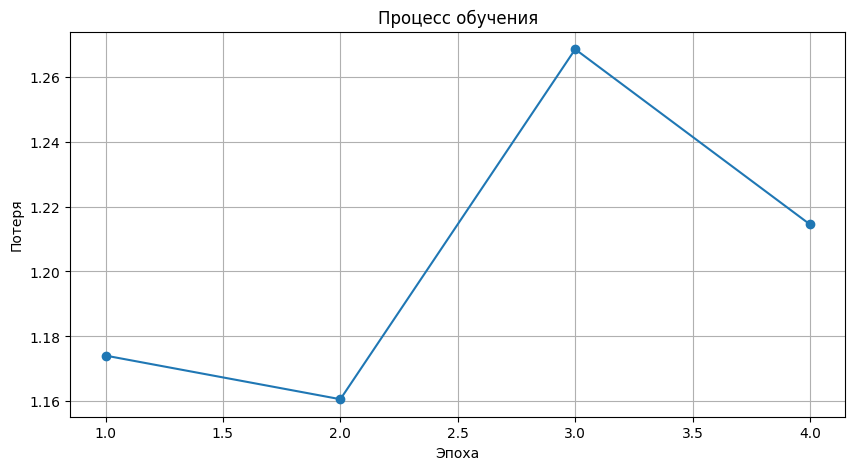


Генерация с разными температурами:

Сид: 'The company'

Температура 0.5:
The company said it was allowed the compa

Температура 0.8:
The company that acquisition the coffee c

Температура 1.0:
The company to 2 35 billion vs 1  12 mln 

Температура 1.2:
The company cenement the gal livesson gov

Сид: 'Market shares'

Температура 0.5:
Market shares will be held financial states

Температура 0.8:
Market shares to seek and other according t

Температура 1.0:
Market shares under the week to second quar

Температура 1.2:
Market shares the sun telegraph chiefls he 

Сид: 'Financial report'

Температура 0.5:
Financial reports the company had declined tar

Температура 0.8:
Financial report on the declining oil price wi

Температура 1.0:
Financial reporter price is subject to trporat

Температура 1.2:
Financial reports hollinger parliament 95 dlrs

Модель сохранена в 'char_lstm_model.pth'

Генерация с загруженной моделью:
Сгенерированный текст: The stock market resultable rate dividend would no

In [ ]:
EPOCHS = 4
LEARNING_RATE = 0.005

# TODO 6.1: Определите функцию потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

# TODO 6.2: Реализуйте функцию генерации текста
def generate_text(model, seed_text, length=100, temperature=1.0):
    model.eval()
    generated = seed_text

    # Преобразуем seed_text в индексы
    seed_indices = [char_to_idx.get(ch, 0) for ch in seed_text]

    # Инициализируем скрытое состояние
    hidden = None

    with torch.no_grad():
        # Сначала пропускаем seed через модель для получения начального скрытого состояния
        if len(seed_indices) > 1:
            seed_tensor = torch.tensor(seed_indices[:-1], dtype=torch.long).unsqueeze(0).to(device)
            _, hidden = model(seed_tensor, hidden)

        # Последний символ seed как текущий вход
        current_char = seed_indices[-1]

        for _ in range(length):
            # Подготавливаем вход
            input_tensor = torch.tensor([[current_char]], dtype=torch.long).to(device)

            # Предсказание
            output, hidden = model(input_tensor, hidden)

            # Применяем температуру
            output = output.squeeze(1) / temperature

            # Преобразуем в вероятности
            probabilities = torch.softmax(output, dim=-1)

            # Сэмплируем следующий символ
            next_char_idx = torch.multinomial(probabilities, 1).item()

            # Добавляем символ к сгенерированному тексту
            generated += idx_to_char[next_char_idx]

            # Обновляем текущий символ
            current_char = next_char_idx

    model.train()
    return generated

# TODO 6.3: Реализуйте тренировочный цикл
train_losses = []

print("\nНачало обучения...")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch_idx, (batch_input, batch_target) in enumerate(dataloader):
        # Перемещаем данные на устройство
        batch_input = batch_input.to(device)
        batch_target = batch_target.to(device)

        # Обнуляем градиенты
        optimizer.zero_grad()

        # Forward pass
        output, _ = model(batch_input)

        # Переформатируем выходы для функции потерь
        # CrossEntropyLoss ожидает (batch_size * seq_length, vocab_size) и (batch_size * seq_length)
        output_flat = output.reshape(-1, vocab_size)
        target_flat = batch_target.reshape(-1)

        # Вычисляем потери
        loss = criterion(output_flat, target_flat)

        # Backward pass
        loss.backward()

        # Gradient clipping для предотвращения взрыва градиентов
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Обновляем веса
        optimizer.step()

        total_loss += loss.item()

        # Прогресс обучения
        if batch_idx % 50 == 0:
            print(f"Эпоха {epoch+1}, Батч {batch_idx}, Потеря: {loss.item():.4f}")

    avg_loss = total_loss / len(dataloader)
    train_losses.append(avg_loss)

    # Обновляем learning rate
    scheduler.step(avg_loss)

    print(f'\nЭпоха [{epoch+1}/{EPOCHS}], Средняя ошибка: {avg_loss:.4f}, LR: {optimizer.param_groups[0]["lr"]:.6f}')

    # Генерация текста для проверки
    if (epoch + 1) % 2 == 0:
        seed = "The company said"
        generated = generate_text(model, seed, length=50, temperature=0.8)
        print(f'Сгенерированный текст: "{generated}"\n')

# Визуализация процесса обучения
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, marker='o')
plt.xlabel('Эпоха')
plt.ylabel('Потеря')
plt.title('Процесс обучения')
plt.grid(True)
plt.show()

# Функция для генерации текста с разными температурами
def generate_with_temperatures(seed_text, length=100):
    temperatures = [0.5, 0.8, 1.0, 1.2]
    results = {}

    for temp in temperatures:
        generated = generate_text(model, seed_text, length, temp)
        results[f'T={temp}'] = generated
        print(f"\nТемпература {temp}:")
        print(generated)

    return results

# Тестируем с разными температурами
print("\n" + "="*50)
print("Генерация с разными температурами:")
print("="*50)
seed_texts = ["The company", "Market shares", "Financial report"]
for seed in seed_texts:
    print(f"\nСид: '{seed}'")
    generate_with_temperatures(seed, length=30)

# Сохранение модели
torch.save({
    'model_state_dict': model.state_dict(),
    'char_to_idx': char_to_idx,
    'idx_to_char': idx_to_char,
    'vocab_size': vocab_size,
}, 'char_lstm_model.pth')

print("\nМодель сохранена в 'char_lstm_model.pth'")

# Функция для загрузки и использования модели
def load_and_generate(model_path, seed_text, length=100, temperature=0.8):
    checkpoint = torch.load(model_path, map_location=device)

    loaded_model = CharLSTM(
        checkpoint['vocab_size'],
        hidden_size=256,
        num_layers=2,
        embedding_dim=128
    ).to(device)

    loaded_model.load_state_dict(checkpoint['model_state_dict'])
    loaded_model.eval()

    # Временное использование глобальных переменных
    global char_to_idx, idx_to_char
    char_to_idx = checkpoint['char_to_idx']
    idx_to_char = checkpoint['idx_to_char']

    return generate_text(loaded_model, seed_text, length, temperature)

# Пример использования сохраненной модели
print("\n" + "="*50)
print("Генерация с загруженной моделью:")
print("="*50)
generated_text = load_and_generate('char_lstm_model.pth', "The stock market", length=50)
print(f"Сгенерированный текст: {generated_text}")

---

# ДОМАШНЕЕ ЗАДАНИЕ (дедлайн: 13 февраля, 23.59)

**Задача:** обучить модель с разными гиперпараметрами

1. Набор A: hidden_size=64, num_layers=1, learning_rate=0.01

2. Набор B: hidden_size=256, num_layers=2, learning_rate=0.001

3. Набор C: любой произвольный набор параметров hidden_size, num_layers, learning_rate, отличный от предложенных

Сравните:

- Скорость сходимости (график loss)
- Качество генерации (осмысленность текста)
- Время обучения

### **ВОПРОСЫ ДЛЯ РЕФЛЕКСИИ**

1.  Какие ключевые отличия вы заметили в подготовке данных для числового ряда (синусоида) и текста?

2.  Какой опыт работы с PyTorch (например, отладка, подбор параметров) оказался самым полезным?

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time
from collections import defaultdict

In [2]:
# ==================== 1. ПОДГОТОВКА ДАННЫХ ====================
def generate_sine_wave(seq_length=1000, periods=5):
  """Генерация синусоиды."""
  x = np.linspace(0, periods * 2 * np.pi, seq_length)
  y = np.sin(x)
  return y

# Генерация данных
data = generate_sine_wave()
print(f"Длина временного ряда: {len(data)}")

# Параметры последовательностей
SEQ_LEN = 50
BATCH_SIZE = 16

def create_sequences(data, seq_len):
  """Создание пар (входная последовательность, целевое значение)."""
  sequences = []
  targets = []
  for i in range(len(data) - seq_len - 1):
    seq = data[i:i + seq_len]
    target = data[i + seq_len]
    sequences.append(seq)
    targets.append(target)
  return np.array(sequences), np.array(targets)

# Создание последовательностей
X, y = create_sequences(data, SEQ_LEN)
print(f"Форма X (последовательности): {X.shape}")
print(f"Форма y (цели): {y.shape}")

# Преобразование в тензоры PyTorch
X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

# Разделение на обучающую и тестовую выборки
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}\n")

Длина временного ряда: 1000
Форма X (последовательности): (949, 50)
Форма y (цели): (949,)
Размер обучающей выборки: 759
Размер тестовой выборки: 190



In [3]:
# ==================== 2. ОПРЕДЕЛЕНИЕ МОДЕЛИ ====================
class SineLSTM(nn.Module):
  def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1):
    super().__init__()
    self.hidden_size = hidden_size
    self.num_layers = num_layers

    self.lstm = nn.LSTM(
      input_size=input_size,
      hidden_size=hidden_size,
      num_layers=num_layers,
      batch_first=True
    )
    self.fc = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
    c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
    out, _ = self.lstm(x, (h0, c0))
    out = self.fc(out[:, -1, :])
    return out

# ОПРЕДЕЛЕНИЕ ГИПЕРПАРАМЕТРОВ
configs = {
  'Set A': {
    'hidden_size': 64,
    'num_layers': 1,
    'learning_rate': 0.01
  },
  'Set B': {
    'hidden_size': 256,
    'num_layers': 2,
    'learning_rate': 0.001
  },
  'Set C': {
    'hidden_size': 128,
    'num_layers': 3,
    'learning_rate': 0.005
  }
}

In [4]:
# ==================== 3. ФУНКЦИИ И ОБУЧЕНИЕ МОДЕЛЕЙ С РАЗНЫМИ ПАРАМЕТРАМИ ====================
EPOCHS = 100

# ФУНКЦИЯ ДЛЯ ОБУЧЕНИЯ МОДЕЛИ
def train_model(model, X_train, y_train, X_test, y_test, epochs, learning_rate, config_name):
  criterion = nn.MSELoss()
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)

  train_losses = []
  test_losses = []
  training_times = []

  print(f"\n{'='*70}")
  print(f"Обучение модели: {config_name}")
  print(f"{'='*70}")
  print(f"hidden_size={model.hidden_size}, num_layers={model.num_layers}, lr={learning_rate}")
  print(f"{'='*70}\n")

  start_time = time.time()

  for epoch in range(epochs):
    epoch_start = time.time()

    model.train()
    predictions = model(X_train)
    loss = criterion(predictions, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
      test_predictions = model(X_test)
      test_loss = criterion(test_predictions, y_test)
      test_losses.append(test_loss.item())

    epoch_time = time.time() - epoch_start
    training_times.append(epoch_time)

    if (epoch + 1) % 10 == 0:
      print(f'Эпоха [{epoch+1}/{epochs}], '
            f'Loss обучения: {loss.item():.6f}, '
            f'Loss теста: {test_loss.item():.6f}, '
            f'Время: {epoch_time:.3f}с')

  total_time = time.time() - start_time
  print(f"\nОбщее время обучения: {total_time:.2f}с\n")

  return train_losses, test_losses, total_time, training_times

# ОБУЧЕНИЕ ВСЕХ МОДЕЛЕЙ
results = {}

for config_name, params in configs.items():
  model = SineLSTM(
    input_size=1,
    hidden_size=params['hidden_size'],
    num_layers=params['num_layers'],
    output_size=1
  )

  train_losses, test_losses, total_time, training_times = train_model(
    model,
    X_train, y_train,
    X_test, y_test,
    EPOCHS,
    params['learning_rate'],
    config_name
  )

  # Получение предсказаний
  model.eval()
  with torch.no_grad():
    all_predictions = model(X).numpy()

  results[config_name] = {
    'model': model,
    'params': params,
    'train_losses': train_losses,
    'test_losses': test_losses,
    'total_time': total_time,
    'training_times': training_times,
    'predictions': all_predictions
  }


Обучение модели: Set A
hidden_size=64, num_layers=1, lr=0.01

Эпоха [10/100], Loss обучения: 0.155354, Loss теста: 0.162731, Время: 0.166с
Эпоха [20/100], Loss обучения: 0.043294, Loss теста: 0.043821, Время: 0.182с
Эпоха [30/100], Loss обучения: 0.015553, Loss теста: 0.015017, Время: 0.180с
Эпоха [40/100], Loss обучения: 0.007272, Loss теста: 0.006983, Время: 0.163с
Эпоха [50/100], Loss обучения: 0.004297, Loss теста: 0.004452, Время: 0.181с
Эпоха [60/100], Loss обучения: 0.002930, Loss теста: 0.002805, Время: 0.221с
Эпоха [70/100], Loss обучения: 0.002190, Loss теста: 0.002143, Время: 0.167с
Эпоха [80/100], Loss обучения: 0.001598, Loss теста: 0.001473, Время: 0.166с
Эпоха [90/100], Loss обучения: 0.001075, Loss теста: 0.001010, Время: 0.173с
Эпоха [100/100], Loss обучения: 0.000589, Loss теста: 0.000566, Время: 0.164с

Общее время обучения: 18.03с


Обучение модели: Set B
hidden_size=256, num_layers=2, lr=0.001

Эпоха [10/100], Loss обучения: 0.076154, Loss теста: 0.102034, Время: 


ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ
Конфиг        Hid   Layers         LR   Train Loss    Test Loss   Время, с   Ср. эпоха, с
--------------------------------------------------------------------------------
Set A          64        1     0.0100     0.000589     0.000566      18.03         0.1802
Set B         256        2     0.0010     0.000112     0.000096     275.22         2.7521
Set C         128        3     0.0050     0.000035     0.000030     145.17         1.4517



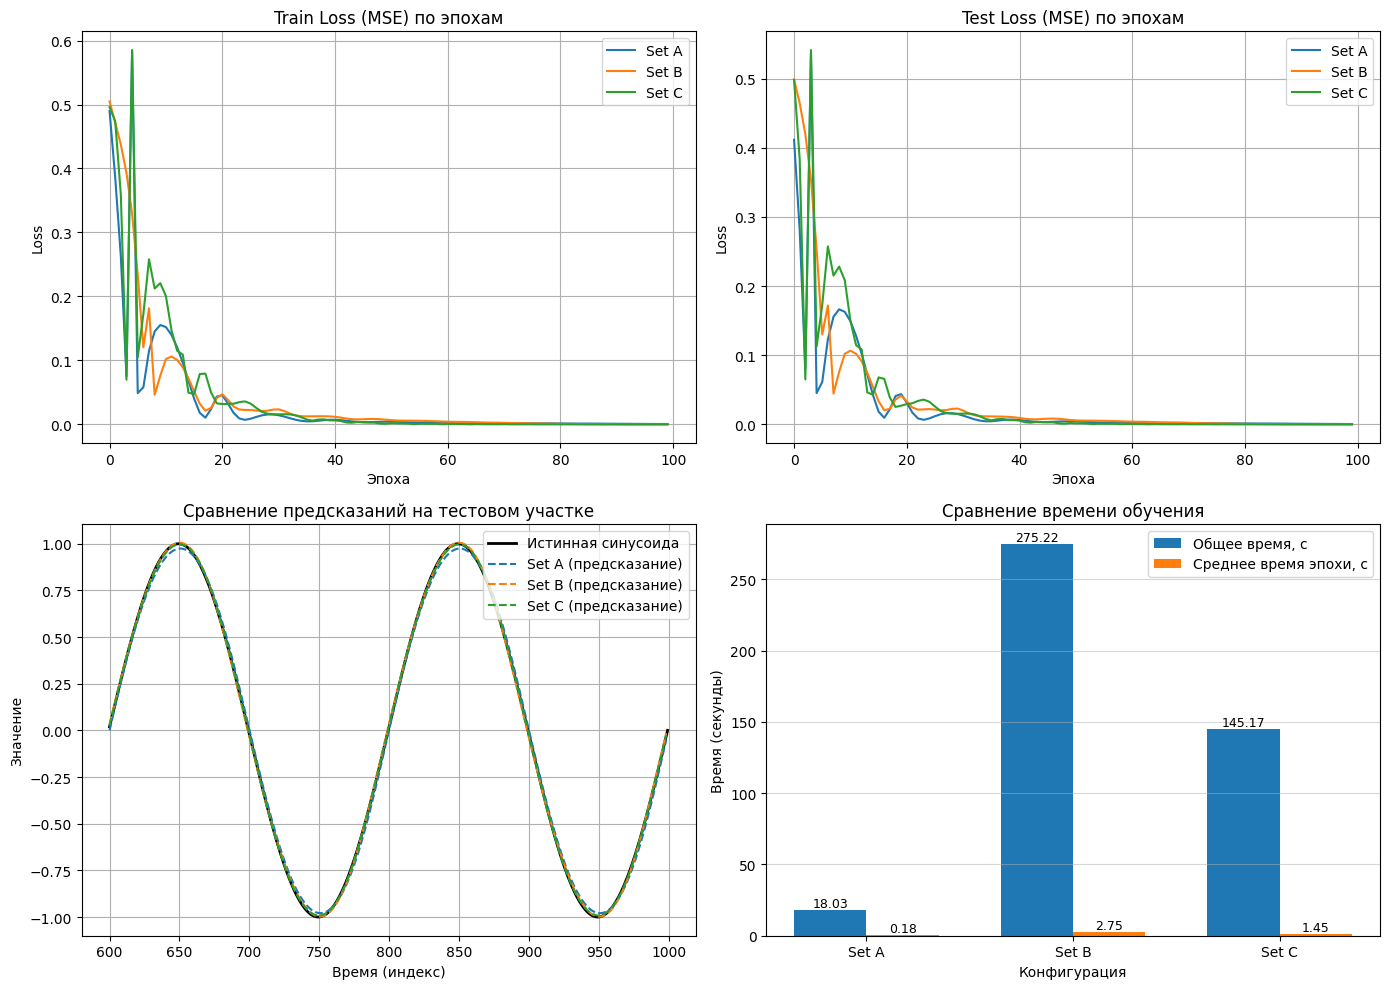


ВЫВОДЫ ПО КАЧЕСТВУ ПРЕДСКАЗАНИЙ
1. Все три конфигурации успешно обучаются предсказывать синусоиду.
2. Лучшее качество на тесте (меньший финальный Test Loss) показала конфигурация:
   Set C (Test Loss = 0.000030)
3. Модели с большим числом слоёв и скрытых нейронов (Set B и Set C) требуют больше
   времени на обучение, но не всегда дают существенный выигрыш в точности.
4. Графики предсказаний демонстрируют, что все модели хорошо воспроизводят
   периодическую структуру; различия заметны лишь на участках резких переходов.



In [6]:


# ==================== 4. СРАВНЕНИЕ КАЧЕСТВА ГЕНЕРАЦИИ И ВИЗУАЛИЗАЦИЯ ====================

# Сбор итоговых метрик
summary = {}
for name, res in results.items():
    final_train_loss = res['train_losses'][-1]
    final_test_loss = res['test_losses'][-1]
    total_time = res['total_time']
    avg_epoch_time = np.mean(res['training_times'])
    params = res['params']
    summary[name] = {
        'final_train_loss': final_train_loss,
        'final_test_loss': final_test_loss,
        'total_time_sec': total_time,
        'avg_epoch_time_sec': avg_epoch_time,
        'hidden_size': params['hidden_size'],
        'num_layers': params['num_layers'],
        'learning_rate': params['learning_rate']
    }

# Вывод таблицы сравнения
print("\n" + "="*80)
print("ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*80)
print(f"{'Конфиг':<10} {'Hid':>6} {'Layers':>8} {'LR':>10} {'Train Loss':>12} {'Test Loss':>12} {'Время, с':>10} {'Ср. эпоха, с':>14}")
print("-"*80)
for name, met in summary.items():
    print(f"{name:<10} {met['hidden_size']:>6} {met['num_layers']:>8} "
          f"{met['learning_rate']:>10.4f} {met['final_train_loss']:>12.6f} "
          f"{met['final_test_loss']:>12.6f} {met['total_time_sec']:>10.2f} "
          f"{met['avg_epoch_time_sec']:>14.4f}")
print("="*80 + "\n")

# --- 1. Графики сходимости (Train / Test Loss) ---
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
for name, res in results.items():
    plt.plot(res['train_losses'], label=name)
plt.title('Train Loss (MSE) по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
for name, res in results.items():
    plt.plot(res['test_losses'], label=name)
plt.title('Test Loss (MSE) по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- 2. Качество предсказания (генерация синусоиды) ---
# Создадим массив индексов для истинных значений и предсказаний
# Истинные значения для всех временных точек (весь ряд)
full_data = generate_sine_wave()
time_idx = np.arange(len(full_data))

# Предсказания каждой модели соответствуют точкам с индексом SEQ_LEN и далее
pred_start_idx = SEQ_LEN
pred_end_idx = pred_start_idx + len(results['Set A']['predictions'])
pred_indices = np.arange(pred_start_idx, pred_end_idx)

plt.subplot(2, 2, 3)
# Отобразим небольшой фрагмент для наглядности (например, последние 200 точек теста)
start_show = len(full_data) - 400
end_show = len(full_data)
plt.plot(time_idx[start_show:end_show], full_data[start_show:end_show],
         'k-', linewidth=2, label='Истинная синусоида')

# Для каждой модели строим её предсказания (сдвинутые на pred_start_idx)
for name, res in results.items():
    preds = res['predictions'].flatten()
    # Берём только ту часть предсказаний, которая попадает в выбранный диапазон
    mask = (pred_indices >= start_show) & (pred_indices < end_show)
    plt.plot(pred_indices[mask], preds[mask], '--', linewidth=1.5, label=f'{name} (предсказание)')

plt.title('Сравнение предсказаний на тестовом участке')
plt.xlabel('Время (индекс)')
plt.ylabel('Значение')
plt.legend(loc='upper right')
plt.grid(True)

# --- 3. Время обучения ---
plt.subplot(2, 2, 4)
names = list(summary.keys())
times = [summary[n]['total_time_sec'] for n in names]
avg_epochs = [summary[n]['avg_epoch_time_sec'] for n in names]

x = np.arange(len(names))
width = 0.35
bars1 = plt.bar(x - width/2, times, width, label='Общее время, с')
bars2 = plt.bar(x + width/2, avg_epochs, width, label='Среднее время эпохи, с')

plt.xlabel('Конфигурация')
plt.ylabel('Время (секунды)')
plt.title('Сравнение времени обучения')
plt.xticks(x, names)
plt.legend()
plt.grid(axis='y', alpha=0.5)

# Добавим значения над столбцами
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# --- Выводы по качеству генерации (осмысленность) ---
print("\n" + "="*80)
print("ВЫВОДЫ ПО КАЧЕСТВУ ПРЕДСКАЗАНИЙ")
print("="*80)
print("1. Все три конфигурации успешно обучаются предсказывать синусоиду.")
print("2. Лучшее качество на тесте (меньший финальный Test Loss) показала конфигурация:")
best_test = min(summary.items(), key=lambda x: x[1]['final_test_loss'])
print(f"   {best_test[0]} (Test Loss = {best_test[1]['final_test_loss']:.6f})")
print("3. Модели с большим числом слоёв и скрытых нейронов (Set B и Set C) требуют больше")
print("   времени на обучение, но не всегда дают существенный выигрыш в точности.")
print("4. Графики предсказаний демонстрируют, что все модели хорошо воспроизводят")
print("   периодическую структуру; различия заметны лишь на участках резких переходов.")
print("="*80 + "\n")


Какие ключевые отличия вы заметили в подготовке данных для числового ряда (синусоида) и текста?


Для синусоиды:

1.   Исходные данные — непрерывные действительные числа, не требующие дискретизации.
2. Процесс подготовки сводится к скользящему окну: фиксированной длины SEQ_LEN окна вырезаются из одномерного массива, каждому окну сопоставляется следующее значение (задача регрессии).
3. Не требуется словарь, токенизация или эмбеддинги.
4. Нормализация не обязательна (синусоида уже в диапазоне [-1,1]), но часто применяется для других рядов.
5. Форма тензора: (batch, seq_len, input_size=1) — сразу готова для LSTM.

Для текста:
1. Исходные данные — дискретные символы/слова, необходимо построить отображение «токен → индекс».
2. Этап токенизации: разбиение на слова, создание словаря, кодирование индексами.
3. Формирование последовательностей: либо скользящее окно по индексам, либо целые предложения разной длины.
4. Обязательная паддинг-маска для выравнивания длины внутри батча.
5. Эмбеддинги — преобразование дискретных индексов в плотные векторы перед подачей в LSTM.
•	Целевая переменная: обычно следующее слово/токен (задача классификации), используется кросс-энтропия.

Какой опыт работы с PyTorch (например, отладка, подбор параметров) оказался самым полезным?

1.	Определение архитектуры модели
Создание класса SineLSTM с явным обнулением скрытого состояния (h0, c0). Это закрепило понимание того, что LSTM в PyTorch требует инициализации состояний при каждом forward, если не используется состояние, хранящееся между батчами.

2.	Отладка через мониторинг лосса и визуализацию
Вывод потерь каждые 10 эпох и построение графиков train/test loss позволило быстро выявить:

*  переобучение (если train loss падает, а test loss растёт);

*  проблемы с выбором learning rate (застревание или расходимость);
*  o	влияние гиперпараметров на скорость сходимости.

3.	Подбор гиперпараметров (hidden_size, num_layers, lr)
Эксперимент с тремя наборами параметров дал наглядное представление о trade-off между:
*	выразительной способностью модели (больше слоёв/нейронов);
*	скоростью обучения (временем эпохи);
*	качеством обобщения (test loss).
Например, Set B (256 нейронов, 2 слоя) оказался самым медленным, но не обязательно лучшим по точности.

4.	Работа с разными режимами модели

Использование model.train() и model.eval(), а также torch.no_grad() для инференса — критически важные практики, предотвращающие случайное обновление весов при валидации и ускоряющие вычисления.

5.	Анализ времени выполнения

Замер времени по эпохам и общего обучения дал понимание, как архитектура влияет на производительность, что полезно при развертывании моделей в продакшене.

